# Analyse av aksjepriser for Wallmart med yfinance 

I denne oppgaven vil jeg bruke yfinance til å hente historiske aksjepriser for de to selskapene Wallmart og Amazon. Begge selskapene selger det meste husholdninger trenger, fra dagligvarer og klær, til farmasøytiske varer. Forskjellen er at Wallmart i størst grad selger i fysiske butikker og Amazon stort sett har netthandel  med levering hjem.

Jeg vil bruke informasjonen fra de historiske aksjeprisene til å drive grunnleggende investeringsanalyse ved å se på:
* Golden crosses og Death crosses
* RSI (relative strength index)

Først vil jeg hente informasjon for de siste 5 år og plotte det med mathplotlib for å se utviklingen.

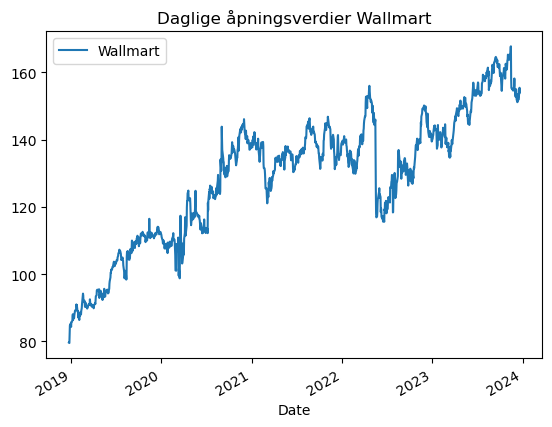

In [210]:
#Importerer nødvendige biblioteker
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np


#Henter aksjeinformasjon til selskapet
wmt = yf.Ticker('WMT')


#Henter daglig aksjeverdi siste 5 år
wmrt_df = wmrt.history(period="5y", interval = "1d")


#Plotter kursutviklingen
wmrt_df["Open"].plot(label="Wallmart")
plt.title("Daglige åpningsverdier Wallmart")
plt.legend()

Vi ser at det er forholdsvis store variasjonen, men at, med unntak av ett kraftigere fall, så er utviklingen stogende. Kursen har omtrent doblet seg fra 80 til 160 på de fe årene. 

### 50-dagers- og 200-dagers-gjennomsnitt for akjseverdien
For å bedre se trendene i utviklingen, altså om aksjeneverdiene er inne i en fase der de har tendens til å stige eller synke, vil jeg finne 50-dagers gjennomsnitt og 200-dagerssnitt for de aksjen. Det gjør jeg ved å finne det glidende gjennomsnittet verdien har hatt de siste 50 eller 200 dagene, og sette det inn i en liste. Det må ha gått 50 eller 200 dager før jeg kan finne verdier for desse snittene, derfor vil listen for tidspunkt fra start til 50 eller 200 dager ikke ha noen verdi (np.nan - not a number).

##### 50-dagers gjennomsnitt


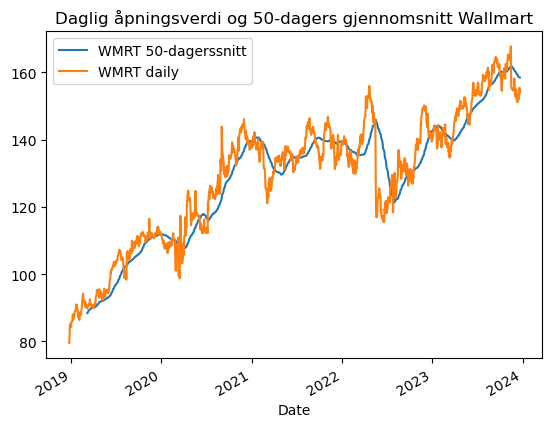

In [211]:
#Definerer tidsintervallet som skal finnes gjennomsnitt over
kort_intervall = 50

#Definerer funksjon for å regne ut glidende gjennomsnitt
def glidende_snitt(priser, n, ind):
    return priser[ind-n:ind].mean()



#Wallmart 50-dagerssnitt
femti_dager_wmrt = [] 
ind = kort_intervall
for i in range(0,ind): 
    femti_dager_wmrt.append(np.nan)
    
for i in range(ind, len(wmrt_df["Open"])): #len angir tidsperioden som er brukt i dataframet
    femti_dager_wmrt.append(glidende_snitt(wmrt_df["Open"], kort_intervall,i))

#Plotter 50-dagerssnittet sammen med daglige verdier for Wallmart
wmrt_df["Femtidagers_snitt"] = femti_dager_wmrt #Legger til 50-dagerssnittet i Wallmarts dataframe
wmrt_df["Femtidagers_snitt"].plot(label = "WMRT 50-dagerssnitt")
wmrt_df["Open"].plot(label = "WMRT daily")
plt.title("Daglig åpningsverdi og 50-dagers gjennomsnitt Wallmart")
plt.legend()
plt.show()


##### 200-dagers gjennomsnitt

Gjør akkurat det samme som for 50-dagers gjennomsnitt, bare med lengre tidsintervall på 200 dager for å finne glidende gjennomsnitt.

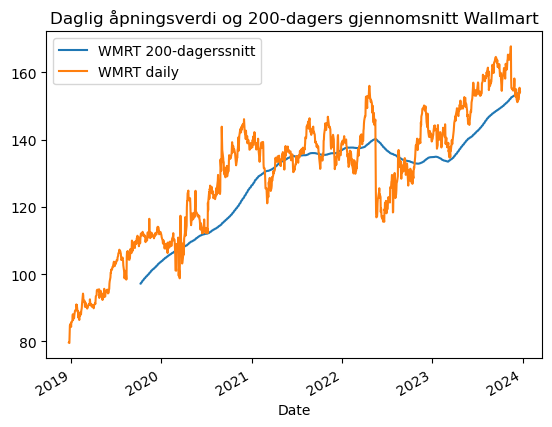

In [212]:
#Definerer tidsintervallet som skal finnes gjennomsnitt over
langt_intervall = 200

#Wallmart 200-dagerssnitt
tohundre_dager_wmrt = [] 
ind = langt_intervall
for i in range(0,ind): 
    tohundre_dager_wmrt.append(np.nan)
    
for i in range(ind, len(wmrt_df["Open"])):
    tohundre_dager_wmrt.append(glidende_snitt(wmrt_df["Open"], langt_intervall,i))

#Plotter 200-dagerssnittet sammen med daglige verdier for Wallmart
wmrt_df["Tohundredagers_snitt"] = tohundre_dager_wmrt #Legger til 200-dagerssnittet i Wallmarts dataframe
wmrt_df["Tohundredagers_snitt"].plot(label = "WMRT 200-dagerssnitt")
wmrt_df["Open"].plot(label = "WMRT daily")
plt.title("Daglig åpningsverdi og 200-dagers gjennomsnitt Wallmart")
plt.legend()
plt.show()


Ikke overraskende er det mindre svingninger i 200-dagerssnittet enn i 50-dagerssnittet. Det er fordi når gjennomsnittet regnes over et lengre intervall utjevnes de daglige svingningene i større grad, og viser hva trenden er over lengre tid. 

### Investeringsanalyse ved hjelp av 50-dagers og 200-dagers gjennomsnitt

Når vi sammenligner kortsiktig og langsiktig gjennomsnitt må de nødvendigvis krysse hverandre med ulike intervall, eller så hadde det vært uendelig stigende vekst (om kortsiktig gjennomsnitt lå over langsiktig intervall). Når 50-dagerssnittet går fra å være lavere enn 200-dagerssnittet til å bli høyere, viser det at den kortsiktige veksttrenden er høyere enn den langsiktige. Dette kryssningspunktet kalles "Golden cross". Når det omvendte skjer, at 50-dagerssnittet går fra å være høyere enn 200-dagerssnittet, til å bli lavere, kalles "Death cross" og er en indikasjon på at den kortsiktige veksttrenden er lavere enn den langsiktige. 

Ved å plotte 50-dagerssnittet og 200-dagerssnittet sammen, kan vi ser når desse kryssingene skjer.

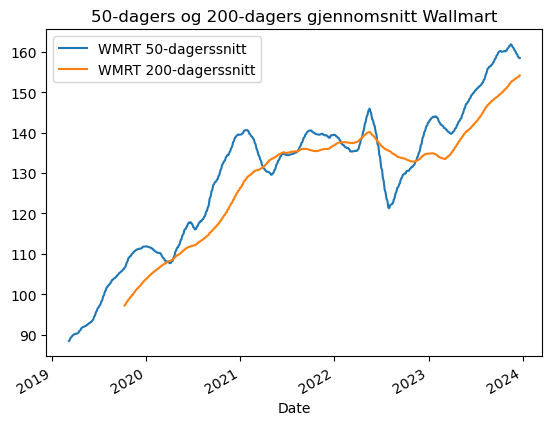

In [213]:
wmrt_df["Femtidagers_snitt"].plot(label = "WMRT 50-dagerssnitt")
wmrt_df["Tohundredagers_snitt"].plot(label = "WMRT 200-dagerssnitt")
plt.title("50-dagers og 200-dagers gjennomsnitt Wallmart")
plt.legend()
plt.show()


Jeg vil undersøke om det gjelder generelt at kjøp på golden cross og salg på death cross gir gevinst. Ved første tanke kan det virke logisk, fordi om en kjøper på golden cross, vil den kortsiktige vekstrrenden vere høyere enn den langsiktige. Da kan det være penger å tjene.

For å finne aksjeverdiene når kryssene skjer, lager jeg to lister, en for aksjeverdien ved golden cross (wmrt_gc) og en for verdien ved death cross (wmrt_dc).

Deretter finner jeg kursendringen fra et golden cross til det følgende death cross. Videre lager jeg en liste med gevinsten ved kjøp på et golden cross og salg på påfølgende death cross. Det kan bli litt komplisert alt etter hva verdiene på kortsiktig og langsiktig snitt er ved starten og slutten av perioden: 

1. Dersom kortsiktig snitt lå **over** langsiktig i starten, og **under** ved slutten, vil det være flere death crosses enn golden crosses
2. Dersom kortsiktig snitt lå **under** langsliktig i starten, og **over** ved slutten, vil det være flere golden crosses enn death crosses
3. Dersom kortsiktig snitt lå **over** langsiktig snitt i starten, og **over** i slutten (eller omvendt) vil det være like mange golden crosses som death crosses

I det første tilfellet vil både det første og det siste krysset være death cross, og siden jeg bare er interessert i å sjekke utviklingen fra et golden cross til påfølgende death cross, må jeg hoppe over første death cross.

I det andre tilfellet vil både det første og siste krysset være golden cross, og jeg må skippe siste golden cross. Både i første og andre tilfelle kan jeg fikse det ved å justere hvor mange iterasjoner som brukes i for-løkken som regner ut kursgevinsten.

I det tredje tilfellet er det rett fram hvis første krysset er golden cross og det siste er death cross. Dersom det er omvendt, må jeg hoppe over første death cross og siste golden cross. Jeg sjekker hva som er tilfellet ved å se hvilken av gjennomsnittene som er størst ved 200 dager, når 200-dagerssnittet starter.

Jeg kunne unngått alt dette ved å se på plottet av gjennomsnittene ovenfor og bare brukt den for-løkken som passet best, men jeg ville skrive en mer generell løkke som kan brukes i alle tilfeller.

In [216]:
#Golden cross for Wallmart
wmrt_gc = []
for i in range(len(wmrt_df)):
    if wmrt_df.iloc[i-1]["Femtidagers_snitt"] < wmrt_df.iloc[i-1]["Tohundredagers_snitt"] and wmrt_df.iloc[i]["Femtidagers_snitt"] > wmrt_df.iloc[i]["Tohundredagers_snitt"] :
        wmrt_gc.append(wmrt_df["Open"].iloc[i])

#Death cross for Wallmart
wmrt_dc = []
for i in range(len(wmrt_df)):
    if wmrt_df.iloc[i-1]["Femtidagers_snitt"] > wmrt_df.iloc[i-1]["Tohundredagers_snitt"] and wmrt_df.iloc[i]["Femtidagers_snitt"] < wmrt_df.iloc[i]["Tohundredagers_snitt"] :
        wmrt_dc.append(wmrt_df["Open"].iloc[i])
        

gevinst = []
if len(wmrt_gc) != len(wmrt_dc) :
    for i in range (len(min(len(wmrt_dc), len(wmrt_gc)))) :
        if len(wmrt_gc) < len(wmrt_dc) :
            gevinst.append(wmrt_dc[i+1] - wmrt_gc[i])
        elif len(wmrt_gc) > len(wmrt_dc) :
            gevinst.append(wmrt_dc[i] - wmrt_gc[i+1])
        
elif len(wmrt_gc) == len(wmrt_dc) and wmrt_df.iloc[200]["Femtidagers_snitt"] > wmrt_df.iloc[200]["Tohundredagers_snitt"] :
    for i in range (len(wmrt_gc)-1) :
        gevinst.append(wmrt_dc[i+1] - wmrt_gc[i])
        
elif len(wmrt_gc) == len(wmrt_dc) and wmrt_df.iloc[200]["Femtidagers_snitt"] < wmrt_df.iloc[200]["Tohundredagers_snitt"] :
    for i in range (len(wmrt_gc)) :
        gevinst.append(wmrt_dc[i] - wmrt_gc[i])
            
print(gevinst)

[8.278478646797069, -11.134957753028118, -36.96299373787532]


Det er altså ikke tilfelle at kjøp på golden cross og salg på death cross gir generell gevinst. Grunnen til det er at i en stigende trend vil gjennomsnittet ha etterslep fordi det blir utjevnet med tidligere verdier, og tilsvarende for synkende trend. Kursen kan altså ha steget mye før kortsiktig snitt går over langsiktig snitt, og fallt mye før kortsiktig snitt går under langsiktig snitt. Jeg trenger altså flere indikatorer enn bare golden/death cross for å avgjøre når det er tid for å kjøpe/selge.

### Investeringsanalyse ved hjelp av RSI

RSI, eller Relative Strength Index, er et annet analyseverktøy. Det måler den relative størrelsen på kursendringen over en (vanligvis) 14-dagersperiode (eller 14 tidsenheter). Dersom RSI-verdien er høy (over 70), viser det at kjøpstrykket er høyt og kursverdien kan være kunstig høy. Dersom RSI-verdien er lav (under 30), viser det at salgstrykket er høyt, og kursen kan være kunstig lav. Høy RSI predikerer altså et fall i kursen, og motsatt ved lav RSI.

RSI går fra 0-100 og finnes ved: RSI = 100 - (100 / (1 + (gjennomsnittlig endring ved gevinst / gjennomsnittlig endring ved tap)))

Gjennomsnittlig endring ved gevinst finnes ved å finne gjennomsnittlig endring de siste 14 dager når kursen har steget. Her settes altså tap til 0 for å ikke trekke gevinsten ned.

Gjennomsnittlig endring ved tap finnes ved å finne gjennomsnittlig endring de siste 14 dager når kursen har gått ned. Her er det gevinsten som settes til 0 for å ikke påvirke tapet.

Open                    9.876830e+01
High                    1.003030e+02
Low                     9.821023e+01
Close                   9.977281e+01
Volume                  7.016400e+06
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.020058e+02
Tohundredagers_snitt             NaN
RSI                     3.414987e+01
Name: 2019-08-06 00:00:00-04:00, dtype: float64

Open                    1.010235e+02
High                    1.092856e+02
Low                     1.007324e+02
Close                   1.087974e+02
Volume                  1.707420e+07
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.096798e+02
Tohundredagers_snitt    1.070393e+02
RSI                     5.083145e+01
Name: 2020-03-02 00:00:00-05:00, dtype: float64

Open                    1.270510e+02
High                    1.279196e+02
Low                     1.255046e+02
Close                   1.259533e+02
Volume                  1.110820e+07
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.377561e+02
Tohundredagers_snitt    1.304994e+02
RSI                     2.811982e+01
Name: 2021-02-25 00:00:00-05:00, dtype: float64

Open                    1.255046e+02
High                    1.258196e+02
Low                     1.239583e+02
Close                   1.240155e+02
Volume                  1.415690e+07
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.374923e+02
Tohundredagers_snitt    1.305520e+02
RSI                     2.569640e+01
Name: 2021-02-26 00:00:00-05:00, dtype: float64

Open                    1.256001e+02
High                    1.265451e+02
Low                     1.251705e+02
Close                   1.253996e+02
Volume                  1.154480e+07
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.371826e+02
Tohundredagers_snitt    1.305900e+02
RSI                     3.031595e+01
Name: 2021-03-01 00:00:00-05:00, dtype: float64

...

Open                    1.169984e+02
High                    1.199197e+02
Low                     1.165978e+02
Close                   1.189036e+02
Volume                  8.412700e+06
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.400844e+02
Tohundredagers_snitt    1.384414e+02
RSI                     3.166273e+01
Name: 2022-06-10 00:00:00-04:00, dtype: float64

Open                    1.163926e+02
High                    1.172426e+02
Low                     1.154547e+02
Close                   1.167150e+02
Volume                  7.181400e+06
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.390027e+02
Tohundredagers_snitt    1.381825e+02
RSI                     2.921437e+01
Name: 2022-06-14 00:00:00-04:00, dtype: float64

Open                    1.172133e+02
High                    1.176432e+02
Low                     1.151909e+02
Close                   1.166369e+02
Volume                  8.638000e+06
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.384167e+02
Tohundredagers_snitt    1.380521e+02
RSI                     2.911826e+01
Name: 2022-06-15 00:00:00-04:00, dtype: float64

Open                    1.156305e+02
High                    1.189622e+02
Low                     1.155133e+02
Close                   1.178484e+02
Volume                  1.023560e+07
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.378228e+02
Tohundredagers_snitt    1.379311e+02
RSI                     3.280782e+01
Name: 2022-06-16 00:00:00-04:00, dtype: float64

Open                    1.155817e+02
High                    1.199588e+02
Low                     1.155035e+02
Close                   1.193628e+02
Volume                  7.972200e+06
Dividends               0.000000e+00
Stock Splits            0.000000e+00
Femtidagers_snitt       1.366028e+02
Tohundredagers_snitt    1.376683e+02
RSI                     3.994453e+01
Name: 2022-06-21 00:00:00-04:00, dtype: float64

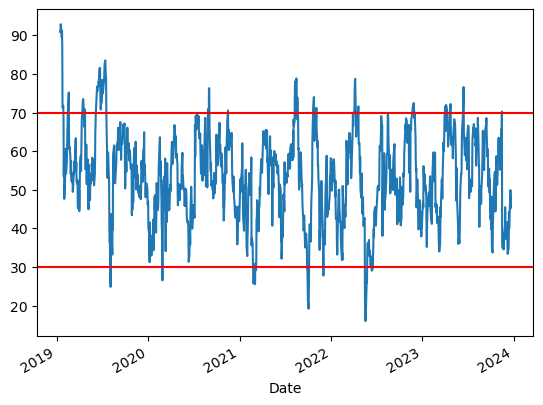

In [217]:
#Lager en funksjon som skal finne RSI
def rsi(wmrt_df, periods = 14, ema = True) :
 
    #Finner differansen mellom kursen ved lukking en dag og dagen før
    lukkekurs_endring = wmrt_df['Close'].diff()

    # Lager to serier, en når differansen er positiv (verdien stiger) og ned når differansen er negativ (kursen synker)
    up = lukkekurs_endring.clip(lower=0) #clip setter alle verdiene som er lavere enn 0 (pga. lower=0) til denne verdien (0)
    down = -lukkekurs_endring.clip(upper=0) #her setter clip alle verdiene over 0 til 0
    
    if ema == True:
	    # Når vi har 14 tidsenheter eller med å regne fra, brukes eksponentiell glidende gjennomsnitt 
        #for å finne daglig gjennomsnittlig stigning og reduksjon i kursen
        ma_up = up.ewm(com = periods - 1, adjust = True, min_periods = periods).mean()
        ma_down = down.ewm(com = periods - 1, adjust = True, min_periods = periods).mean()
    else:
        # Før vi har nått 14 tidsenheter, brukes glidende gjennomsnitt
        ma_up = up.rolling(window = periods, adjust = False).mean()
        ma_down = down.rolling(window = periods, adjust = False).mean()
        
    rsi = 100 - (100 / (1 + (ma_up / ma_down)))
    return rsi


wmrt_rsi = rsi(wmrt_df)

wmrt_df["RSI"] = wmrt_rsi

wmrt_rsi.plot()
plt.axhline(y = 70, color = "red")
plt.axhline(y = 30, color = "red")

for i in range(len(wmrt_df)-1):
    if wmrt_df.iloc[i]["RSI"] < 30 :
           display(wmrt_df.iloc[i+1])

Det fordeler seg forholdsvis jevnt om "Close" er høyere enn "Open" når RSI er under 30, men dette er innenfor samme dag. Jeg vil undersøke om det lønner seg generelt å kjøpe aksjer når RSI er under 30 og selge neste gang RSI går over 70. Jeg velger å gjøre det ved å først finne indeksverdien i wmrt_df når RSI-verdien først faller under 30, og deretter finne indeksverdien når RSI stiger over 70 første gang etter den sank under 30. Videre finner jeg neste gang RSI faller under 30 igjen, osv. Desse indeksverdiene setter jeg sammen som par i et nytt datasett (wmrt_df_rsi). Da kan jeg bruke indeksverdiene til å finne differansen mellom kursen ved salg på høy RSI og kjøp på lav RSI.

For å sette sammen det nye datasettet wmrt_df_rsi prøvde jeg først å bruke pd.append, og det fungerte også, men ga irriterende tilbakemelding om at funksjonen skal utfases. Jeg endret derfor til å lage en midlertidig df (temp_df) og bruke pd.concat i stedet.

In [219]:
high = 70
low = 30

#Tilbakestiller indeks til generiske tall fra 0 til n for å kunne bruke indekstallet for å finne kursen ved høy og lav RSI
wmrt_df.reset_index(drop = False, inplace = True) #Beholder den gamle indekskolonnen som kolonne, men overskriver datasettet

#Oppretter nytt dataframe der jeg vil ha indeksverdiene når RSI går under 30 og over 70
wmrt_df_rsi = pd.DataFrame(columns = ["RSI < 30", "RSI > 70"])

#Starter med indeks 0 i wmrt_df når funksjonen leter etter verdiene
indeks = 0

#Lager en while-løkke for å gjenta operasjonene til hele datasettet er gjennomgått 
while True :
    #Finner første gang verdien synker under 30. None på sluttes returnerer None dersom next-funksjonen ikke finner noen
    #verdier som oppfyller kriteriene jeg har satt.
    index_low = next((index for index, value in wmrt_df["RSI"].iloc[indeks:].items() if value < low), None)
    
    if index_low is not None : #Hvis next-funksjonen ovenfor returnerer None, skippes dette steget.
        index_high = next((index for index, value in wmrt_df["RSI"].iloc[index_low:].items() if value > high), None)
        
        if index_high is not None :
            temp_df = pd.DataFrame({"RSI < 30": [index_low],
                                    "RSI > 70": [index_high]})
                                    
            wmrt_df_rsi = pd.concat([wmrt_df_rsi, temp_df], ignore_index = True)
                
            indeks = index_high + 1
        else :
            break #Stopper løkken om den ikke finner noen brukbare verdier
    else :
        break

#Lager en liste med differansen mellom kursene ved tidspunktene høy og lav
wmrt_df_rsi_gevinst = []
for i in range (len(wmrt_df_rsi)) :
    wmrt_df_rsi_gevinst.append(wmrt_df.iloc[wmrt_df_rsi.iloc[i]["RSI > 70"]]["Open"] - wmrt_df.iloc[wmrt_df_rsi.iloc[i]["RSI < 30"]]["Open"])

#Legger til gevinsten i ny kolonne i datasettet
wmrt_df_rsi["Gevinst"] = wmrt_df_rsi_gevinst

wmrt_df_rsi

,RSI < 30,RSI > 70,Gevinst
0,153,423,33.649999
1,545,661,11.734537
2,695,713,5.041713
3,741,825,13.979309
4,855,986,15.859032


Ut fra dette (begrensede) datasettet ser det ut til at RSI er en bedre indikator på når en bør kjøpe og selge aksjer enn golden/death cross. Her gir alle seriene med kjøp og salg gevinst. Det må selvsagt prøves på mange flere datasett for å være en studie som i seg selv kan konkludere med om det faktisk er generelt, eller berre et spesielt tilfelle med aksjene til Wallmart i akkurat denne perioden.

## Kjøre hele programmet på en annen aksje

Under har jeg samlet hele programmet hittil i en mer generisk form, der brukeren kan skrive inn sin egen askje hen vil sjekke ut. Jeg har bevisst tatt med importeringen av bibliotekene og definert alt på nytt for at denne cellen skal kunne være 100% selvstendig og kjøres uten at noen av cellene ovenfor er kjørt. Jeg har også hentet en annen funksjon for å finne RSI fra pandas_ta, da denne gjør det raskt med en linje i stedet for å lage funksjonen fra starten av. Den bruker, på samme måte som funksjonen for RSI ovenfor, glidende gjennomsnitt for tiden før 14 dager, og eksponentielt glidende snitt etter 14 dager. Dersom pandas_ta ikke er installert, har jeg med en egen celle som installerer det først.  

In [ ]:
#!pip install pandas_ta

Hva heter selskapet? 
Amazon


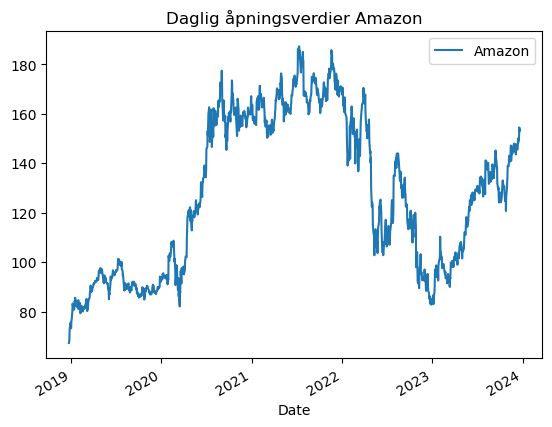

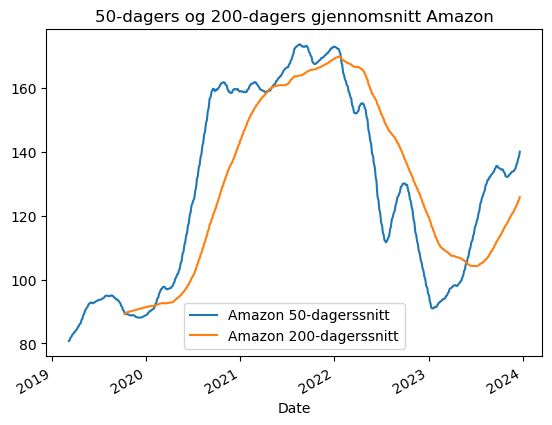

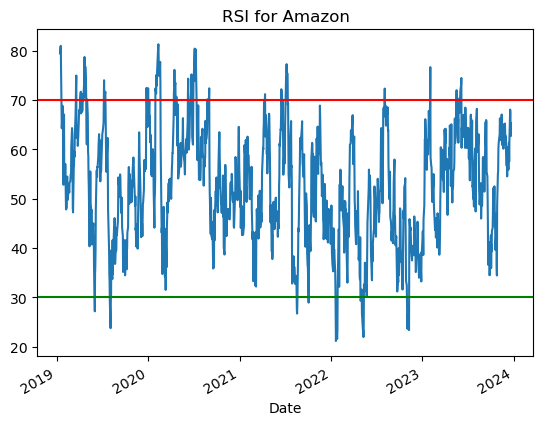

Dersom du kjøpte på Golden Cross og solgte på Death Cross vill du hatt kursgevinst [67.46549224853516, -29.486495971679688]


,RSI < 30,RSI > 70,Gevinst
0,109,134,9.389496
1,152,253,-2.203003
2,667,908,-25.889496
3,971,1034,6.260002


In [235]:
#Importerer nødvendige biblioteker
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas_ta as pta


#Henter aksjeinformasjon til selskapet og spør om navnet, så det kan brukes senere
stock = yf.Ticker('AMZN')
stock_name = input("Hva heter selskapet? \n")

#Henter daglig aksjeverdi siste 5 år
stock_df = stock.history(period="5y", interval = "1d")

#Plotter kursutviklingene
stock_df["Open"].plot(label=f"{stock_name}")
plt.title(f"Daglig åpningsverdier {stock_name}")
plt.legend()
plt.show()


#Definerer tidsintervallet som skal finnes gjennomsnitt over
kort_intervall = 50

#Definerer funksjon for å regne ut glidende gjennomsnitt
def glidende_snitt(priser, n, ind):
    return priser[ind-n:ind].mean()


#Aksjens 50-dagerssnitt
femti_dager_stock = [] 
ind = kort_intervall
for i in range(0,ind): 
    femti_dager_stock.append(np.nan)
    
for i in range(ind, len(stock_df["Open"])): #len angir tidsperioden som er brukt i dataframet
    femti_dager_stock.append(glidende_snitt(stock_df["Open"], kort_intervall,i))

#Legger til 50-dagerssnittet i aksjens dataframe
stock_df["Femtidagers_snitt"] = femti_dager_stock



#Definerer tidsintervallet som skal finnes gjennomsnitt over
langt_intervall = 200

#Aksjens 200-dagerssnitt
tohundre_dager_stock = [] 
ind = langt_intervall
for i in range(0,ind): 
    tohundre_dager_stock.append(np.nan)
    
for i in range(ind, len(stock_df["Open"])):
    tohundre_dager_stock.append(glidende_snitt(stock_df["Open"], langt_intervall,i))

#Legger til 200-dagerssnittet i aksjens dataframe
stock_df["Tohundredagers_snitt"] = tohundre_dager_stock


#Plotter 50-dagers og 200-dagers gjennomsnitt
stock_df["Femtidagers_snitt"].plot(label = f"{stock_name} 50-dagerssnitt")
stock_df["Tohundredagers_snitt"].plot(label = f"{stock_name} 200-dagerssnitt")
plt.title(f"50-dagers og 200-dagers gjennomsnitt {stock_name}")
plt.legend()
plt.show()


#Golden cross for Wallmart
stock_gc = []
for i in range(len(stock_df)):
    if stock_df.iloc[i-1]["Femtidagers_snitt"] < stock_df.iloc[i-1]["Tohundredagers_snitt"] and stock_df.iloc[i]["Femtidagers_snitt"] > stock_df.iloc[i]["Tohundredagers_snitt"] :
        stock_gc.append(stock_df["Open"].iloc[i])

        
#Death cross for Wallmart
stock_dc = []
for i in range(len(stock_df)):
    if stock_df.iloc[i-1]["Femtidagers_snitt"] > stock_df.iloc[i-1]["Tohundredagers_snitt"] and stock_df.iloc[i]["Femtidagers_snitt"] < stock_df.iloc[i]["Tohundredagers_snitt"] :
        stock_dc.append(stock_df["Open"].iloc[i])

#Finner gevinst ved kjøp på golden cross og salg pådeath cross
gevinst_stock = []
if len(stock_gc) != len(stock_dc) :
    for i in range (len(min(len(stock_dc), len(stock_gc)))) :
        if len(stock_gc) < len(stock_dc) :
            gevinst_stock.append(stock_dc[i+1] - stock_gc[i])
        elif len(stock_gc) > len(stock_dc) :
            gevinst_stock.append(stock_dc[i] - stock_gc[i+1])
        
elif len(stock_gc) == len(stock_dc) :
    for i in range (len(stock_gc)-1) :
        if stock_df.iloc[200]["Femtidagers_snitt"] > stock_df.iloc[200]["Tohundredagers_snitt"] :
            gevinst_stock.append(stock_dc[i+1] - stock_gc[i])
        elif stock_df.iloc[200]["Femtidagers_snitt"] < stock_df.iloc[200]["Tohundredagers_snitt"] :
            gevinst_stock.append(stock_dc[i] - stock_gc[i+1])

            
#Bruker pandas_ta sin funksjon for å finne RSI            
stock_rsi = pta.rsi(stock_df['Close'], length = 14) 

#Legger til kolonne for RSI i stock_df
stock_df["RSI"] = stock_rsi


#Definerer high og low
high = 70
low = 30

#Legger til linjene for høy og lav RSI og plotter RSI
stock_df["RSI"].plot()
plt.axhline(y = high, color = "red")
plt.axhline(y = low, color = "green")
plt.title(f"RSI for {stock_name}")
plt.show()


#Tilbakestiller indeks til generiske tall fra 0 til n for å kunne bruke indekstallet for å finne kursen ved høy og lav RSI
stock_df.reset_index(drop = False, inplace = True)


#Oppretter nytt dataframe der jeg vil ha indeksverdiene når RSI går under 30 og over 70
stock_df_rsi = pd.DataFrame(columns = ["RSI < 30", "RSI > 70"])

#Starter med indeks 0 i stock_df når funksjonen leter etter verdiene
indeks = 0

#Lager en while-løkke for å gjenta operasjonene til hele datasettet er gjennomgått 
while True :
    #Finner første gang verdien synker under 30. None på sluttes returnerer None dersom next-funksjonen ikke finner noen
    #verdier som oppfyller kriteriene jeg har satt.
    index_low = next((index for index, value in stock_df["RSI"].iloc[indeks:].items() if value < low), None)
    
    if index_low is not None : #Hvis next-funksjonen ovenfor returnerer None, skippes dette steget.
        index_high = next((index for index, value in stock_df["RSI"].iloc[index_low:].items() if value > high), None)
        
        if index_high is not None :
            stock_temp_df = pd.DataFrame({"RSI < 30": [index_low],
                                    "RSI > 70": [index_high]})
                                    
            stock_df_rsi = pd.concat([stock_df_rsi, stock_temp_df], ignore_index = True)
                
            indeks = index_high + 1
        else :
            break #Stopper løkken om den ikke finner noen brukbare verdier
    else :
        break

#Lager en liste med differansen mellom kursene ved tidspunktene høy og lav
stock_df_rsi_gevinst = []
for i in range (len(stock_df_rsi)) :
    stock_df_rsi_gevinst.append(stock_df.iloc[stock_df_rsi.iloc[i]["RSI > 70"]]["Open"] - stock_df.iloc[stock_df_rsi.iloc[i]["RSI < 30"]]["Open"])

#Legger til gevinsten i ny kolonne i datasettet
stock_df_rsi["Gevinst"] = stock_df_rsi_gevinst
               

print(f"Dersom du kjøpte på Golden Cross og solgte på Death Cross vill du hatt kursgevinst {gevinst_stock}")

stock_df_rsi

## Avsluttende kommentar

Gitt at brukeren har brukt Amazon i programmet ovenfor, ser vi at Amazon kommer bedre ut av det ved kjøp og salg på golden cross og death cross enn Wallmart. Samtidig kommer brukeren dårligere ut av det ved å kjøpe på RSI < 30 og selge på RSI > 70. En mulig årsak til det er at Amazon sine aksjer har vært mye mer volatile, altså svinget mer og krafigere, enn Wallmart sine aksjer. Likevel har vi fått svar på spørsmålet tidligere om kjøp på RSI < 30 og salg på RSI > 70 alltid vil gi gevinst. Det vil det definitivt ikke. 

Når aksjene er inne i en death cross periode ligger prisen på aksjene under langsiktig trendverdi. Det kan være et tidspunkt å kjøpe på, for om selskapet er solid, vil kursen gjerne stige senere. 

Når RSI er høy kan det også være fordi aksjene har en urealistisk lav verdi, og derfor blir altså trykket av kjøpere ekstra stort, fordi de forventer at kursen kommer til å stige for å korrigere dette.

Både golden/death crosses og RSI er verktøy som en investor bør bruke sammen med andre verktøy, trender i markedet, nyheter om hendelser i verden som påvirker aksjemarkedet, kvartalsrapporter, osv. for å gjøre en helhetlig vurdering av mulighetene for gevinst.